In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson as simps
from scipy.ndimage import gaussian_filter1d
from scipy.special import hyp2f1, legendre, spherical_jn
from scipy.fftpack import dst, idst
from scipy.interpolate import InterpolatedUnivariateSpline, interp1d, RectBivariateSpline, splev, splrep, UnivariateSpline
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels, PLaxfromClass
import pickle, tqdm, functools
import vegas

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

In [2]:
fx=0.1
ma=1.e-25
# kref =8.4e12 * pow(ma/0.67,1/2) * 0.666**0.25
kref =8.4e12 * pow(ma/0.67,1/2) * 1**0.25

fullt=np.linspace(-6,1, 200)
p=2
plclass = PLaxfromClass(fx=fx, m_a_ev=ma, zeval=0.)
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=2)
def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

PLc_int = plclass.PLc_int

In [3]:
kref =8.4e12 * pow(1.e-29/0.67,1/2) * 1**0.25


In [4]:
# k=np.logspace(-5,2,1000)
# PL_cc = PLc_int(k)
# gvals = g_numk(k)
# plt.semilogx(k, gvals)
# plt.show()

# np.savetxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/__pycache__/P-ma27.txt', np.column_stack((k,PL_cc,PL_cc*gvals)), header='k, Pcc, Pcchi')

In [5]:
def pksmooth_dst(kL, plinear, kmin):
    
    nk = int(2**15)
    kmax = 5
    klin = np.linspace(kmin, kmax, nk)

    pklin = PLc_int(klin)
    # DST-II log(k *P(k))
    logkpk = np.log10(klin * pklin)
    dstpk = dst(logkpk, type=2)
    # Split in even and odd indices,
    even = dstpk[0::2] # array with even indexes
    odd  = dstpk[1::2] # array with odd indexes
    i_even = np.arange(len(even)).astype(int)
    i_odd  = np.arange(len(odd)).astype(int)
    even_cs = splrep(i_even, even, s=0)
    odd_cs  = splrep(i_odd, odd, s=0)

    # Compute second derivatives and interp separately with cubic splines
    even_2nd_der = splev(i_even, even_cs, der=2, ext=0)
    odd_2nd_der = splev(i_odd, odd_cs, der=2, ext=0)

    # Find i_min and i_max for the even and odd arrays
    # These are optimised for the considered krange [1e-4,10]
    imin_even = i_even[100:300][np.argmax(even_2nd_der[100:300])] - 30
    imax_even = i_even[100:300][np.argmin(even_2nd_der[100:300])] + 70
    imin_odd = i_odd[100:300][np.argmax(odd_2nd_der[100:300])] - 30
    imax_odd = i_odd[100:300][np.argmin(odd_2nd_der[100:300])] + 75

    # Cut out the BAOs
    # mask indices
    i_even_holed = np.concatenate((i_even[:imin_even], i_even[imax_even:]))
    i_odd_holed = np.concatenate((i_odd[:imin_odd], i_odd[imax_odd:]))
    # mask log(k*P(k))
    even_holed = np.concatenate((even[:imin_even], even[imax_even:]))
    odd_holed = np.concatenate((odd[:imin_odd], odd[imax_odd:]))
    # interp the arrays rescaled by a factor (i + 1)^2 using cubic splines
    even_holed_cs = splrep(i_even_holed, even_holed*(i_even_holed+1)**2, s=0)
    odd_holed_cs = splrep(i_odd_holed, odd_holed * (i_odd_holed+1)**2, s=0)

    # Merge the two arrays without the bumps, and without the rescaling
    # factor of (i + 1)^2, and inversely FST
    even_smooth = splev(i_even, even_holed_cs, der=0, ext=0) / (i_even+1)**2
    odd_smooth = splev(i_odd, odd_holed_cs, der=0, ext=0) / (i_odd + 1)**2

    dstkpk_smooth = np.zeros(nk)
    dstkpk_smooth[0::2] = even_smooth
    dstkpk_smooth[1::2] = odd_smooth

    pksmooth = idst(dstkpk_smooth, type=2) / (2 * len(dstkpk_smooth))
    pksmooth = 10**(pksmooth) / klin

    high_k = kL[kL > 2]
    high_p = plinear[kL > 2]
    k_ext = np.concatenate((klin[klin<=2], high_k))
    p_ext = np.concatenate((pksmooth[klin<=2], high_p))

    pksmooth_tot = splrep(np.log(k_ext), np.log(p_ext), s=0)
    smooth_itp = np.exp(splev(np.log(kL), pksmooth_tot, der=0, ext=0))

    return kL, smooth_itp

In [6]:
k=np.logspace(-5,2,1000)
PL_cc = PLc_int(k)

_, Pnw = pksmooth_dst(k, PL_cc, 2.e-5)

Pw = PL_cc - Pnw
Pnw_int=interp1d(k,Pnw)
Pw_int=interp1d(k,Pw)

Pnwcut = Pnw
kLcut=k
lOsc=102.707
norm = 1./(6.*np.pi**2)
Sigma2  = norm*simps(Pnwcut*(1.-spherical_jn(0,kLcut*lOsc)+
                                2.*spherical_jn(2,kLcut*lOsc)), x=kLcut)
dSigma2 = norm*simps(3.*Pnwcut*spherical_jn(2,kLcut*lOsc), x=kLcut)
print(Sigma2)
Damp = np.exp(-k**2 * Sigma2)

34.14490153125034


In [163]:
# plt.loglog(k,(PL_cc))
# plt.loglog(k,(Pnw+Damp*Pw))

# plt.loglog(k,k*(PL_cc))
# plt.loglog(k,k*(Pnw+Damp*Pw))
plt.show()

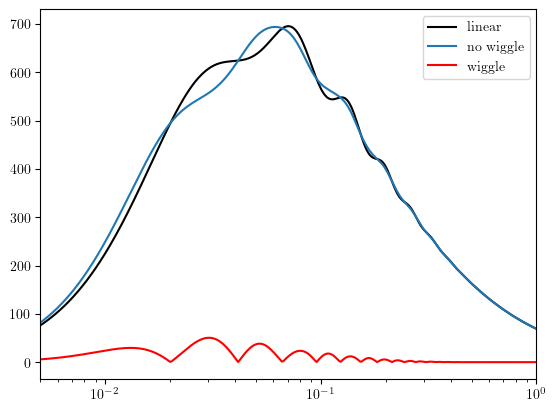

In [139]:
plt.plot(k,k*PL_cc, 'k', label='linear')
plt.plot(k,k*Pnw, 'tab:blue', label='no wiggle')

plt.plot(k,k*np.abs(Pw), 'red', label='wiggle')
plt.xscale('log')
# plt.ylim([1.,None])
plt.xlim([5.e-3,1])

plt.legend()
plt.show()

integrate to get 1-loop

In [7]:
fact=(2*np.pi)**3

def F3(k,q,mu):
    k2=k*k;q2=q*q;mu2=mu*mu
    kMq2 = k2 + q2 - 2*k*q*mu 
    kPq2 = k2 + q2 + 2*k*q*mu 

    res1 = 1/kMq2*(5/126*k2-11/108*k*q*mu+7/108*q2*mu2-1/54*k2*k2*mu2/q2+4/189*k2*k*mu2*mu/q-23/756*k2*k*mu/q+25/252*k2*mu2-2/27*k*q*mu2*mu)
    res2 = 1/kPq2*(5/126*k2+11/108*k*q*mu-7/108*q2*mu2-4/27*k2*k2*mu2/q2-53/189*k2*k*mu2*mu/q+23/756*k2*k*mu/q-121/756*k2*mu2-5/27*k*q*mu2*mu)
    return res1+res2
def F2(k,q,mu):
    k2=k*k;q2=q*q;mu2=mu*mu
    kMq2 = k2 + q2 - 2*k*q*mu 
    return (k2*(7*k*q*mu+3*q2)-10*k2*q2*mu2)/(14*q2*kMq2)

def alpha(k1,k2,cT):
    return 1+cT*k2/k1

def alphas(k1,k2,cT):
    return 1+0.5*cT*(k2/k1+k1/k2)

def beta(k1,k2,cT):
    t1=k1*k1+k2*k2+2*k1*k2*cT
    t2=k1*k2*cT
    t3=2.*k1*k1*k2*k2
    return t1*t2/t3


In [51]:
kevList=np.logspace(np.log10(0.05),np.log10(0.3),70)
# kevList=[0.15]
reslist=[]
def P1loop_EdS_int(vars,kev, PL_int):
    q=vars[0]
    mu=vars[1]
    P13=6*q*q*F3(kev,q,mu)*PL_int(q)*PL_int(kev)
    kMq = np.sqrt(kev*kev + q*q - 2*kev*q*mu)
    kPq = np.sqrt(kev*kev + q*q + 2*kev*q*mu)
    P22=0
    if kMq>q:
        P22+=2*q*q*F2(kev,q,mu)*F2(kev,q,mu)*PL_int(q)*PL_int(kMq)
    if kPq>q:
        P22+=2*q*q*F2(kev,q,-mu)*F2(kev,q,-mu)*PL_int(q)*PL_int(kPq)
    return (P13+P22)*4*np.pi/fact
integ = vegas.Integrator([[1.e-4, 10], [0., 1.]],mpi=True, nproc=48)

print('Training')
result = integ(functools.partial(P1loop_EdS_int, kev=0.1, PL_int=PLc_int),neval=10000)
print('Applying')

Neval = 1000
reslist = np.array(list(reslist))
reslist=[]
for kev in kevList:
    result_full = integ(functools.partial(P1loop_EdS_int, kev=kev, PL_int=PLc_int),neval=Neval)
    result_nw = integ(functools.partial(P1loop_EdS_int, kev=kev, PL_int=Pnw_int),neval=Neval)
    result_w = integ(functools.partial(P1loop_EdS_int, kev=kev, PL_int=Pw_int),neval=Neval)

    reslist.append([kev, result_full.mean, result_nw.mean, result_w.mean])
    print(f'Computing at k={kev:.3f}', end='\r')
np.savetxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/__pycache__/ol-m27.txt', np.array(reslist))

Training
Applying


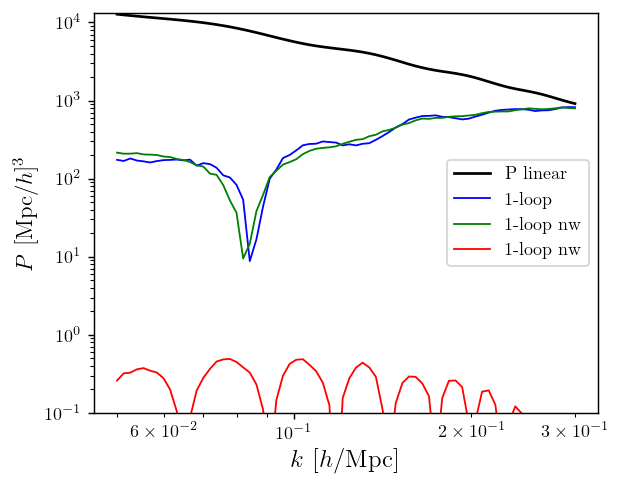

In [140]:
plt.figure(figsize=(5,4), dpi=130)

kev, ol_full, ol_nw, ol_w =np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/__pycache__/ol.txt', unpack=True)
# fromm1 = reslist
plt.plot(kev,PLc_int(kev),'k',label=r'P linear')

plt.plot(kev,np.abs(ol_full), 'b', linewidth=1,label=r'1-loop')
plt.plot(kev,np.abs(ol_nw), 'g', linewidth=1,label=r'1-loop nw')
plt.plot(kev,np.abs(ol_w), 'r', linewidth=1,label=r'1-loop nw')



plt.xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
plt.ylabel(r"$P$ $[\mathrm{Mpc}/h]^3$", fontsize=13)
plt.ylim([0.1, None])
plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/P-1loop-fx0p1.pdf', bbox_inches='tight')

plt.show()

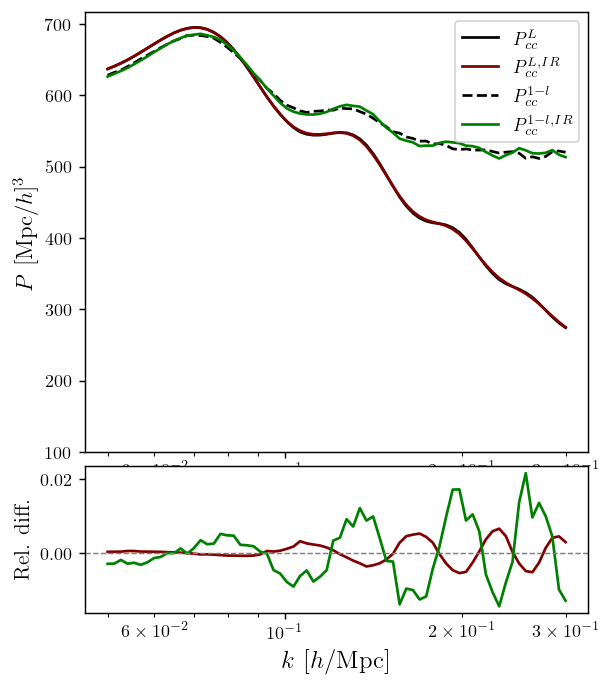

In [141]:
fig, ax = plt.subplots(2, 1, figsize=(5, 6), dpi=130, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# Upper panel
ax[0].plot(kev, kev * PLc_int(kev), 'k', label=r'$P^{L}_{cc}$ ')
P_IR_lin=Pnw_int(kev) + np.exp(-kev**2 * Sigma2)* (1+kev**2 * Sigma2) * Pw_int(kev)
ax[0].plot(kev, kev * P_IR_lin, 'maroon', label=r'$P^{L,IR}_{cc}$ ')
ax[0].plot(kev, kev * (PLc_int(kev) + ol_full), 'k', linestyle='--', label=r'$P^{1-l}_{cc}$ ')
P_IR_1loop =P_IR_lin + ol_nw + np.exp(-kev**2 * Sigma2) * ol_w
ax[0].plot(kev, kev * P_IR_1loop, 'g', label=r'$P^{1-l,IR}_{cc}$ ')

ax[0].set_xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
ax[0].set_ylabel(r"$P$ $[\mathrm{Mpc}/h]^3$", fontsize=13)
ax[0].set_ylim([100, None])
ax[0].set_xscale('log')
ax[0].legend()

# Lower panel (relative differences)
rel_diff_1 = P_IR_lin/ PLc_int(kev) -1
rel_diff_2 = P_IR_1loop / (PLc_int(kev) + ol_full)-1

ax[1].plot(kev, rel_diff_1, 'maroon', label=r'Rel. diff. $P^{L,IR}_{cc}$')
ax[1].plot(kev, rel_diff_2, 'g', label=r'Rel. diff. $P^{1-l,IR}_{cc}$')

ax[1].set_xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
ax[1].set_ylabel(r"Rel. diff.", fontsize=12)
ax[1].set_xscale('log')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.show()

----
Now for the cross power spectra $P_{c\chi}$

In [17]:
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=2)
def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

In [221]:
Pnwcut_Theta_r = Pnwcut*(1-2*h_numk(kLcut)+h_numk(kLcut)**2)

Sigma2_r  = norm*simps(Pnwcut_Theta_r*(1.-spherical_jn(0,kLcut*lOsc)+
                                2.*spherical_jn(2,kLcut*lOsc)), x=kLcut)
print(Sigma2_r)
Damp_r = np.exp(-k**2 * Sigma2_r)

0.888920783151154


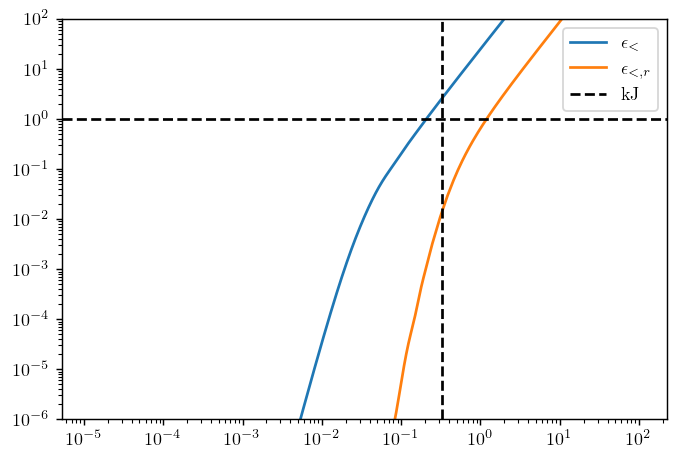

In [222]:
sigmalist=[]

for kup in k[10:]:
    s = norm*simps(Pnwcut[k<kup]*(1.-spherical_jn(0,k[k<kup]*lOsc)+
                                2.*spherical_jn(2,k[k<kup]*lOsc)), x=k[k<kup])

    sr = norm*simps(Pnwcut_Theta_r[k<kup]*(1.-spherical_jn(0,k[k<kup]*lOsc)+
                                2.*spherical_jn(2,k[k<kup]*lOsc)), x=k[k<kup])
    sigmalist.append([s,sr])
epsm,epsm_r =np.array(sigmalist).T
plt.figure(figsize=(6,4), dpi=130)
plt.loglog(k[10:], k[10:]**2 * epsm, label=r'$\epsilon_< $')
plt.loglog(k[10:], k[10:]**2 * epsm_r, label=r'$\epsilon_{<,r} $')
plt.axvline(kref, label='kJ', color='k', linestyle='--')
plt.axhline(1., color='k', linestyle='--')
plt.legend()
plt.ylim([1.e-6,100])
plt.show()

In [62]:
kevList=np.logspace(np.log10(0.05),np.log10(0.3),70)
reslist=[]
def P1loop_cx_int(vars,kev, PL_int):
    q=vars[0]
    mu=vars[1]
    P13=6*q*q*g_numk(kev)*F3(kev,q,mu)*PL_int(q)*PL_int(kev)
    kMq = np.sqrt(kev*kev + q*q - 2*kev*q*mu)
    kPq = np.sqrt(kev*kev + q*q + 2*kev*q*mu)
    P22=0
    if kMq>q:
        P22+=2*q*q*g_numk(kev)*F2(kev,q,mu)*F2(kev,q,mu)*PL_int(q)*PL_int(kMq)
    if kPq>q:
        P22+=2*q*q*g_numk(kev)*F2(kev,q,-mu)*F2(kev,q,-mu)*PL_int(q)*PL_int(kPq)
    return (P13+P22)*4*np.pi/fact
integ = vegas.Integrator([[1.e-4, 10], [0., 1.]],mpi=True, nproc=48)

print('Training')
result = integ(functools.partial(P1loop_cx_int, kev=0.1, PL_int=PLc_int),neval=10000)
print('Applying')
    
reslist = np.array(list(reslist))
reslist=[]
for kev in kevList:
    result_full = integ(functools.partial(P1loop_cx_int, kev=kev, PL_int=PLc_int),neval=500)
    result_nw = integ(functools.partial(P1loop_cx_int, kev=kev, PL_int=Pnw_int),neval=500)
    result_w = integ(functools.partial(P1loop_cx_int, kev=kev, PL_int=Pw_int),neval=500)

    reslist.append([kev,result_full.mean, result_nw.mean, result_w.mean])
    print(f'Result at k={kev:.3f} is {result}', end='\r')
np.savetxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/__pycache__/ol-cx-m27.txt', np.array(reslist))

Training
Applying


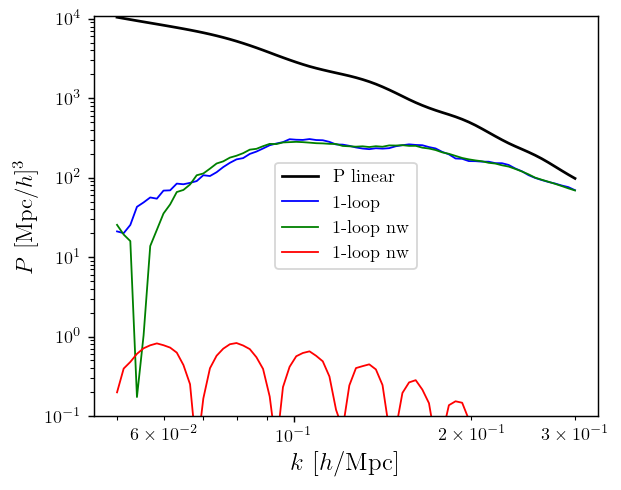

In [71]:
plt.figure(figsize=(5,4), dpi=130)
kev, ol_cx_full, ol_cx_nw, ol_cx_w =np.loadtxt('/home/fverdian/class/soundspeed-scripts/numerical-integrals/__pycache__/ol-cx-m27.txt', unpack=True)

# fromm1 = reslist
plt.plot(kev,PLc_int(kev)*g_numk(kev),'k',label=r'P linear')

plt.plot(kev,np.abs(ol_cx_full), 'b', linewidth=1,label=r'1-loop')
plt.plot(kev,np.abs(ol_cx_nw), 'g', linewidth=1,label=r'1-loop nw')
plt.plot(kev,np.abs(ol_cx_w), 'r', linewidth=1,label=r'1-loop nw')



plt.xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
plt.ylabel(r"$P$ $[\mathrm{Mpc}/h]^3$", fontsize=13)
plt.ylim([0.1,None])
plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/P-1loop-fx0p1.pdf', bbox_inches='tight')

plt.show()

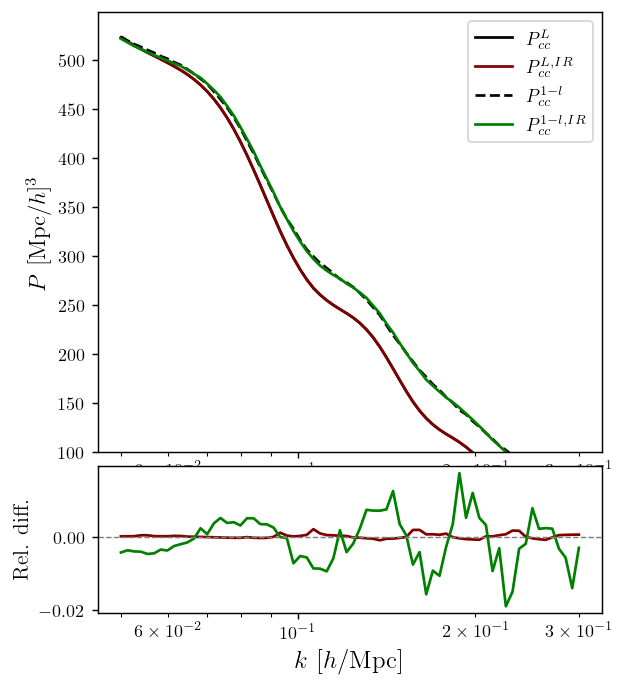

In [70]:
fig, ax = plt.subplots(2, 1, figsize=(5, 6), dpi=130, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# Upper panel
ax[0].plot(kev, kev * PLc_int(kev)*g_numk(kev), 'k', label=r'$P^{L}_{cc}$ ')
ax[0].plot(kev, kev * (Pnw_int(kev)*g_numk(kev) + np.exp(-kev**2 * Sigma2_r) * Pw_int(kev)*g_numk(kev)), 'maroon', label=r'$P^{L,IR}_{cc}$ ')
ax[0].plot(kev, kev * (PLc_int(kev)*g_numk(kev) + ol_cx_full), 'k', linestyle='--', label=r'$P^{1-l}_{cc}$ ')
ax[0].plot(kev, kev * (Pnw_int(kev)*g_numk(kev) + ol_cx_nw + np.exp(-kev**2 * Sigma2_r) * (Pw_int(kev)*g_numk(kev) + ol_cx_w)), 'g', label=r'$P^{1-l,IR}_{cc}$ ')

ax[0].set_xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
ax[0].set_ylabel(r"$P$ $[\mathrm{Mpc}/h]^3$", fontsize=13)
ax[0].set_ylim([100, None])
ax[0].set_xscale('log')
ax[0].legend()

# Lower panel (relative differences)
rel_diff_1 = (Pnw_int(kev)*g_numk(kev) + np.exp(-kev**2 * Sigma2_r) * Pw_int(kev)*g_numk(kev))/ (PLc_int(kev)*g_numk(kev))-1
rel_diff_2 = (Pnw_int(kev)*g_numk(kev) + ol_cx_nw + np.exp(-kev**2 * Sigma2_r) * (Pw_int(kev)*g_numk(kev) + ol_cx_w)) / ((PLc_int(kev)*g_numk(kev) + ol_cx_full))-1

ax[1].plot(kev, rel_diff_1, 'maroon', label=r'Rel. diff. $P^{L,IR}_{cc}$')
ax[1].plot(kev, rel_diff_2, 'g', label=r'Rel. diff. $P^{1-l,IR}_{cc}$')

ax[1].set_xlabel(r"$k$ [$h/\mathrm{Mpc}$]", fontsize=14)
ax[1].set_ylabel(r"Rel. diff.", fontsize=12)
ax[1].set_xscale('log')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.show()

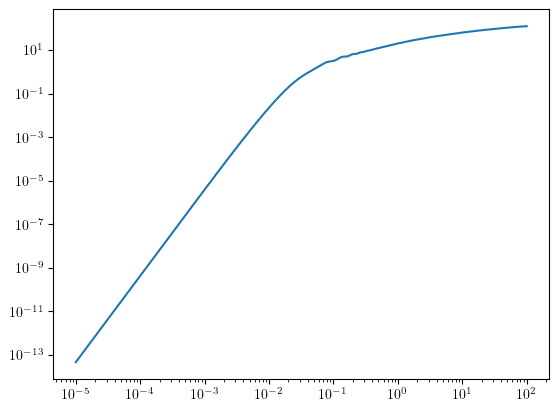

In [225]:
plt.loglog(k,PL_cc*k**3)

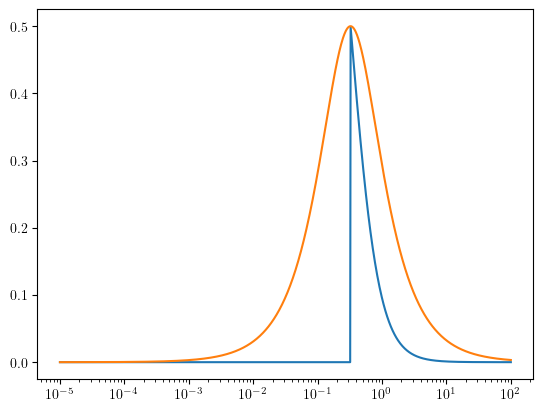

In [ ]:
plt.semilogx(k, 1/(1+(k/kref)**(2 )* np.heaviside(k-kref,0.5))
plt.semilogx(k, (k/kref)/(1+(k/kref)**2 ))


----

In [26]:
import mcfit
k=np.logspace(-5,2,1000)
PL_cc = PLc_int(k)
r, xi = mcfit.P2xi(k)(PL_cc)

r_g, xi_g = mcfit.P2xi(k)(PL_cc*g_numk(k))

/home/fverdian/anaconda3/lib/python3.10/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


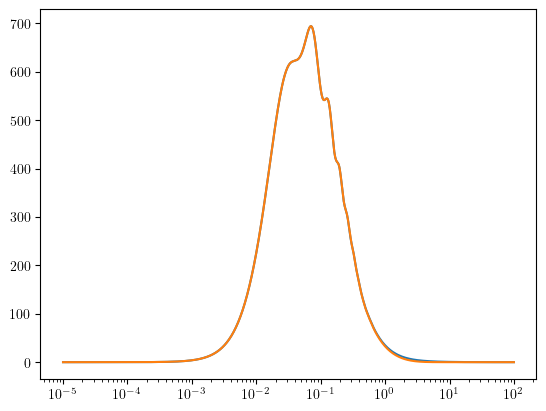

In [27]:
plt.semilogx(k,k*PL_cc)
plt.semilogx(k,k*PL_cc*g_numk(k))

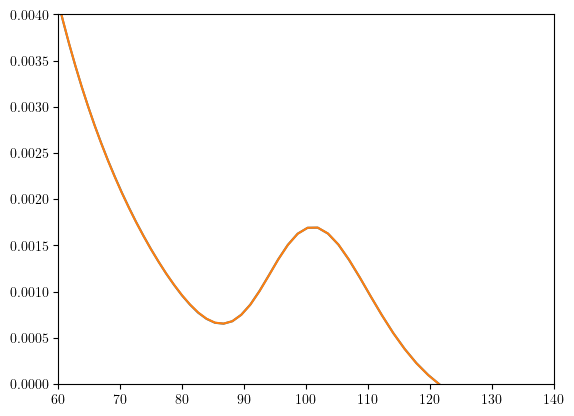

In [33]:
plt.plot(r,xi)
plt.plot(r_g,xi_g)

plt.xlim(60,140)
plt.ylim([0,4.e-3])
plt.show()

----
compare IR resummations

In [13]:

def CallEH_NW(k,PL):
    ns   = 0.96
    h    = 0.67810
    Obh2 = 0.022
    Och2 = 0.142-0.022
    Tcmb = 2.715

    Omh2 = Obh2 + Och2
    kL = k
    kL *= h
    s = 44.5 * np.log(9.83/Omh2) / np.sqrt(1.+10.*(Obh2)**0.75)
    Gamma = Omh2 / h
    AG = (1. - 0.328 * np.log(431.*Omh2) * Obh2 / Omh2 +
            0.38 * np.log(22.3 * Omh2) * (Obh2 / Omh2)**2)
    Gamma = Gamma * (AG + (1.-AG) / (1.+(0.43*kL*s)**4))
    Theta = Tcmb / 2.7
    q  = kL * Theta**2 / Gamma / h
    L0 = np.log(2.*np.e + 1.8*q)
    C0 = 14.2 + 731. / (1. + 62.5 * q)
    T0 = L0 / (L0 + C0 * q * q)
    T0 /= T0[0]
    P_EH  = kL**ns * T0**2
    P_EH *= PL[0] / P_EH[0]
    kL /= h

    return kL, P_EH

def _gaussianFiltering(lamb,kL,  PL):

    def extrapolateX(x):
        logx = np.log10(x); xSize = x.size; dlogx = np.log10(x[1]/x[0])
        newlogx = np.linspace(logx[0]  - xSize * dlogx / 2.,
                            logx[-1] + xSize * dlogx / 2., 2*xSize)
        newx = 10.**newlogx
        return newx

    def extrapolateFx(x, Fx):
        newx   = extrapolateX(x)
        backB  = math.log(Fx[1] / Fx[0]) / math.log(x[1] / x[0])
        backA  = Fx[0] / x[0]**backB
        forwB  = math.log(Fx[-1] / Fx[-2]) / math.log(x[-1] / x[-2])
        forwA  = Fx[-1] / x[-1]**forwB
        backFx = backA * newx[:x.size//2]**backB
        forwFx = forwA * newx[3*x.size//2:]**forwB
        return np.hstack((backFx, Fx, forwFx))

    kNumber = len(kL)
    qlog  = np.log10(kL)
    dqlog = qlog[1]-qlog[0]
    qlog  = np.log10(extrapolateX(kL))
    PLinear = extrapolateFx(kL, PL)
    _, PEH = CallEH_NW(kL, PL)

    PEH = extrapolateFx(kL, PEH)
    Psmooth = gaussian_filter1d(PLinear/PEH, lamb/dqlog)*PEH

    return Psmooth[kNumber//2:kNumber//2+kNumber]

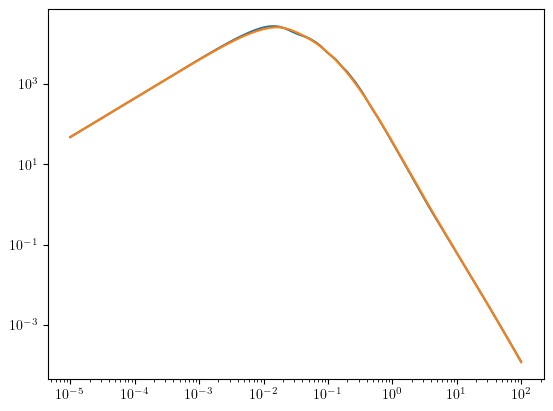

In [16]:
k=np.logspace(-5,2,1000)
PL_cc = PLc_int(k)

_, Pnw = pksmooth_dst(k, PL_cc, 2.e-5)
_, PEH = CallEH_NW(k, PL_cc)
Pgf = _gaussianFiltering(0.25,k, PL_cc)

plt.loglog(k,Pnw)
# plt.loglog(k,PEH)
plt.loglog(k,Pgf)
